# 空间坐标描述

# 空间坐标描述实战
本节包含
- 使用numpy表示位置矢量和旋转矩阵
- 使用numpy进行平移与旋转坐标变换
- 了解ROS2中TF2的概念
- 使用tf2相关CLI工具进行坐标变换
- 使用python操作TF进行坐标变换

## numpy表示位姿

In [ ]:
import numpy as np
import math 

# 位置表示
## 使用3*1的矩阵表示位置，我们新建一个沿着x、y、z各平移1个单位的位置矢量。
np.asarray([1.0,1.0,1.0]).reshape([3,1])

# 位姿表示
## 姿态可以使用3*3的旋转矩阵表示,3*3的单位矩阵代表没有姿态变换，注意没有姿态变换不是零矩阵，而是单位矩阵。
## 我们新建一个旋转矩阵，用该旋转矩阵表示绕着z轴旋转45度
theta = math.radians(45)
R_AB = np.asarray([math.cos(theta),-math.sin(theta),0,
                   math.sin(theta),math.cos(theta),0,
                   0,0,1]).reshape([3,3])
print(R_AB) 

## numpy坐标变换
1.相机坐标系{C}为参考坐标系，工具坐标系{P}的位置矢量在相机坐标系{C}的x,y,z各轴投影为2,1,2，并且工具坐标系和相机坐标系姿态相同。

2.机器人基坐标系{B}为参考坐标系，相机坐标系{C}的位置矢量在{B}各轴的投影为0,0,3，坐标系{C}绕着坐标系{B}的x轴转了180度
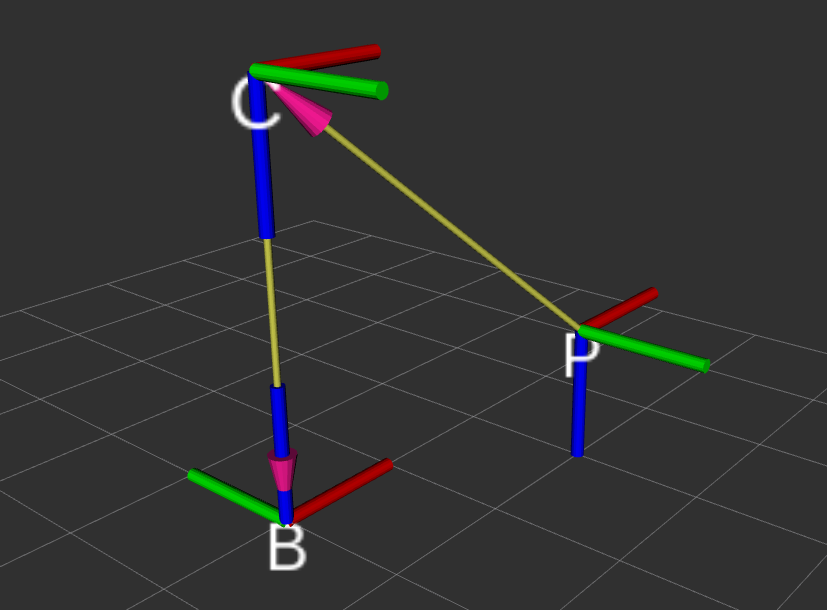 

求：{B}为参考坐标系，坐标系{P}的位置矢量和旋转矩阵

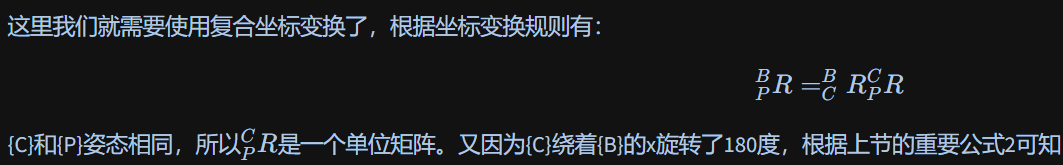


In [ ]:
import math
import numpy as np
theta = math.radians(180)
R_BC = np.asarray([1,0,0,
                   0,math.cos(theta),-math.sin(theta),
                   0,math.sin(theta),math.cos(theta)]).reshape(3,3)
R_BP = R_BC*np.identity(3)
print("旋转矩阵R_BP:\n",R_BP)


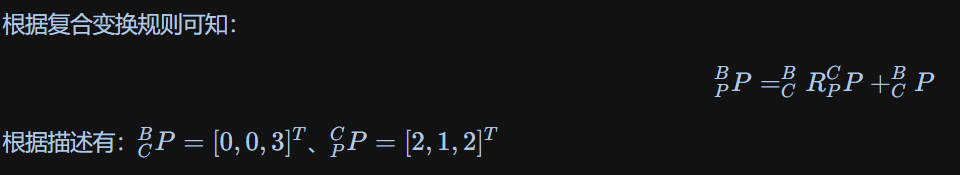

In [ ]:
P_BC = np.asarray([0,0,3]).reshape(3,1)
P_CP = np.asarray([2,1,2]).reshape(3,1)
P_BP = np.add(np.dot(R_BC,P_CP),P_BC)
print("位置矢量P_BP:\n",P_BP.T)


# 姿态表示
常用的坐标描述分为三类，共五种。
- 旋转矩阵-旋转矩阵
- 坐标轴旋转-固定轴欧拉角,非固定轴欧拉角
- 任意轴旋转-等效轴角,四元数

常用的坐标转换包括：
- 固定角与四元数互转
- 固定角与旋转矩阵互转
- 四元数与旋转矩阵互转

## 旋转矩阵
旋转矩阵采用的是旋转后的坐标系三个轴分别与原坐标系三个轴的夹角余弦值共九个数字组成的3*3矩阵。

旋转矩阵一般记作R

>若两个坐标系姿态相同，其旋转矩阵为单位矩阵。

### **旋转矩阵的描述**  
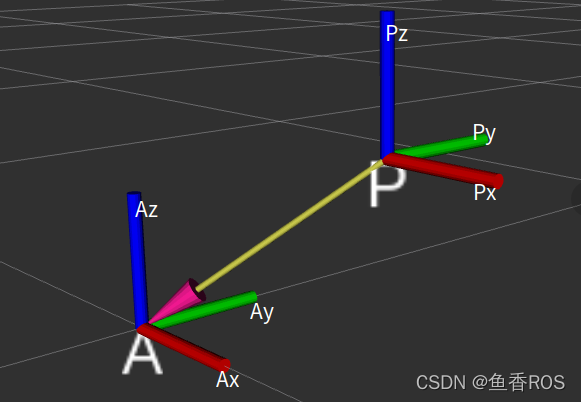
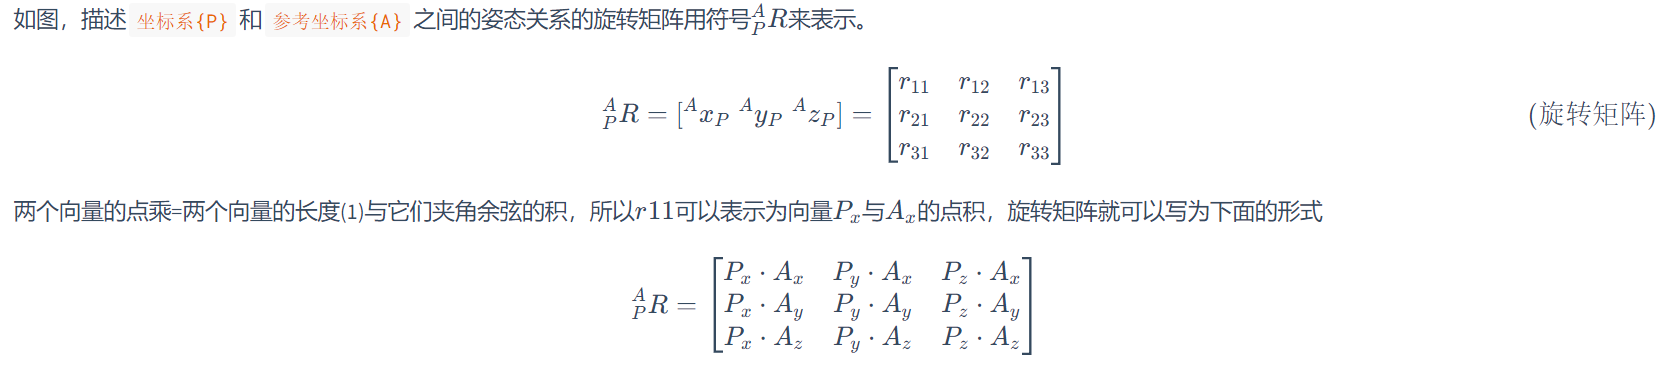

### **绕某一轴旋转θ角的旋转矩阵**  
新的坐标系绕原坐标系某一坐标轴旋转任意角度得到的旋转矩阵有如下等式  
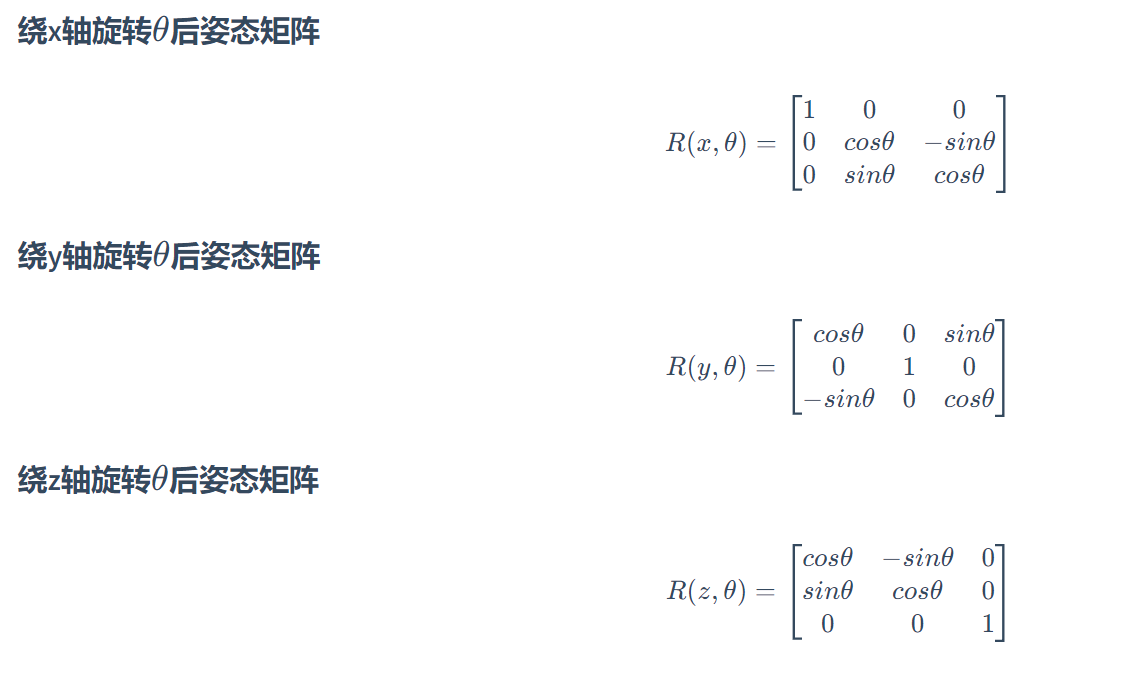

## 欧拉角-绕坐标轴的旋转
### **12种旋转顺序**    

假如知道坐标系绕分别绕X、Y、Z轴的旋转角度，按照特定的顺序将对应的旋转矩阵乘起来就可以确定一个旋转矩阵。

但需要注意的是，矩阵的乘法不具备交换性，所以旋转顺序不同会造成不同的结果。

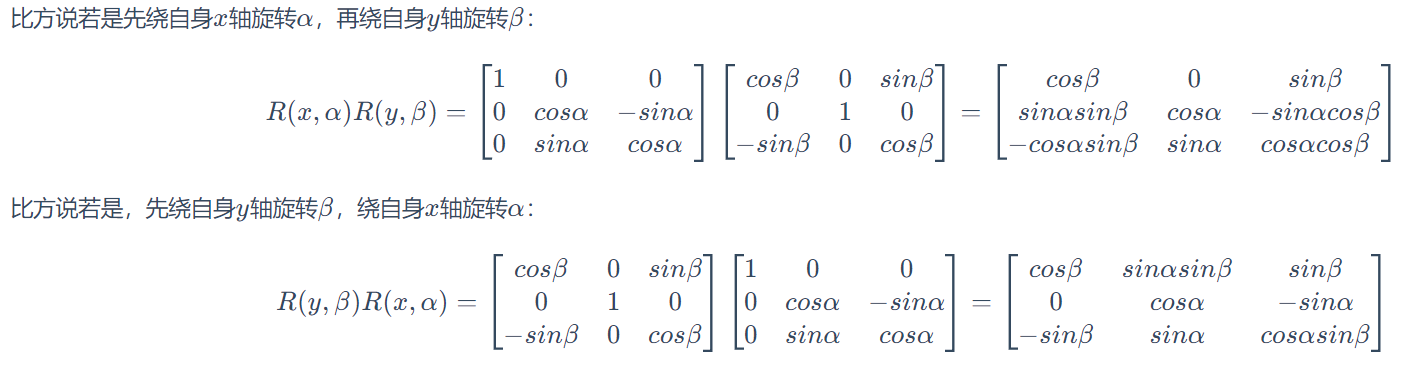

所以我们对旋转顺序做排列组合，可以得到12种旋转顺序:  
xyz,xyx, xzy，xzx,yzx, yzy，yxz, yxy , zxy，zxz, zyx, zyz

### **两种参考坐标系**  
除了要考虑旋转时所绕轴的顺序，还要考虑参考坐标系（坐标轴）的不同。

参考固定的坐标系  
![image.png](http://fishros.com/d2lros2/humble/chapt6/get_started/3.%E5%A7%BF%E6%80%81%E7%9A%84%E5%A4%9A%E7%A7%8D%E8%A1%A8%E7%A4%BA/imgs/808db9fe269b4684bc0537e3154f2a32.gif)

假设坐标系B与坐标系A初始姿态相同

- 坐标系{B}绕坐标系A的x轴Ax旋转α
- 接着坐标系{B}绕着A的y轴Ay旋转β
- 接着绕Az旋转γ

上述三次旋转，都是以A坐标系的xyz轴为参考坐标系进行旋转，该旋转方式为固定旋转轴的旋转，通常称之为固定角欧拉角或固定轴旋转。

参考自身坐标系  
![](http://fishros.com/d2lros2/humble/chapt6/get_started/3.%E5%A7%BF%E6%80%81%E7%9A%84%E5%A4%9A%E7%A7%8D%E8%A1%A8%E7%A4%BA/imgs/fa42e7371bf84f848eaf55c4406699b5.gif)  
也可以不沿着坐标系A的各轴旋转，而是绕旋转之后B的某一轴再次旋转，我们称之为非固定旋转轴的欧拉角

>无论是参考自身坐标系还是参考固定的坐标系，都有12种旋转方式，所以欧拉角有12*2=24种旋转方式

### **固定转轴欧拉角 转 旋转矩阵**
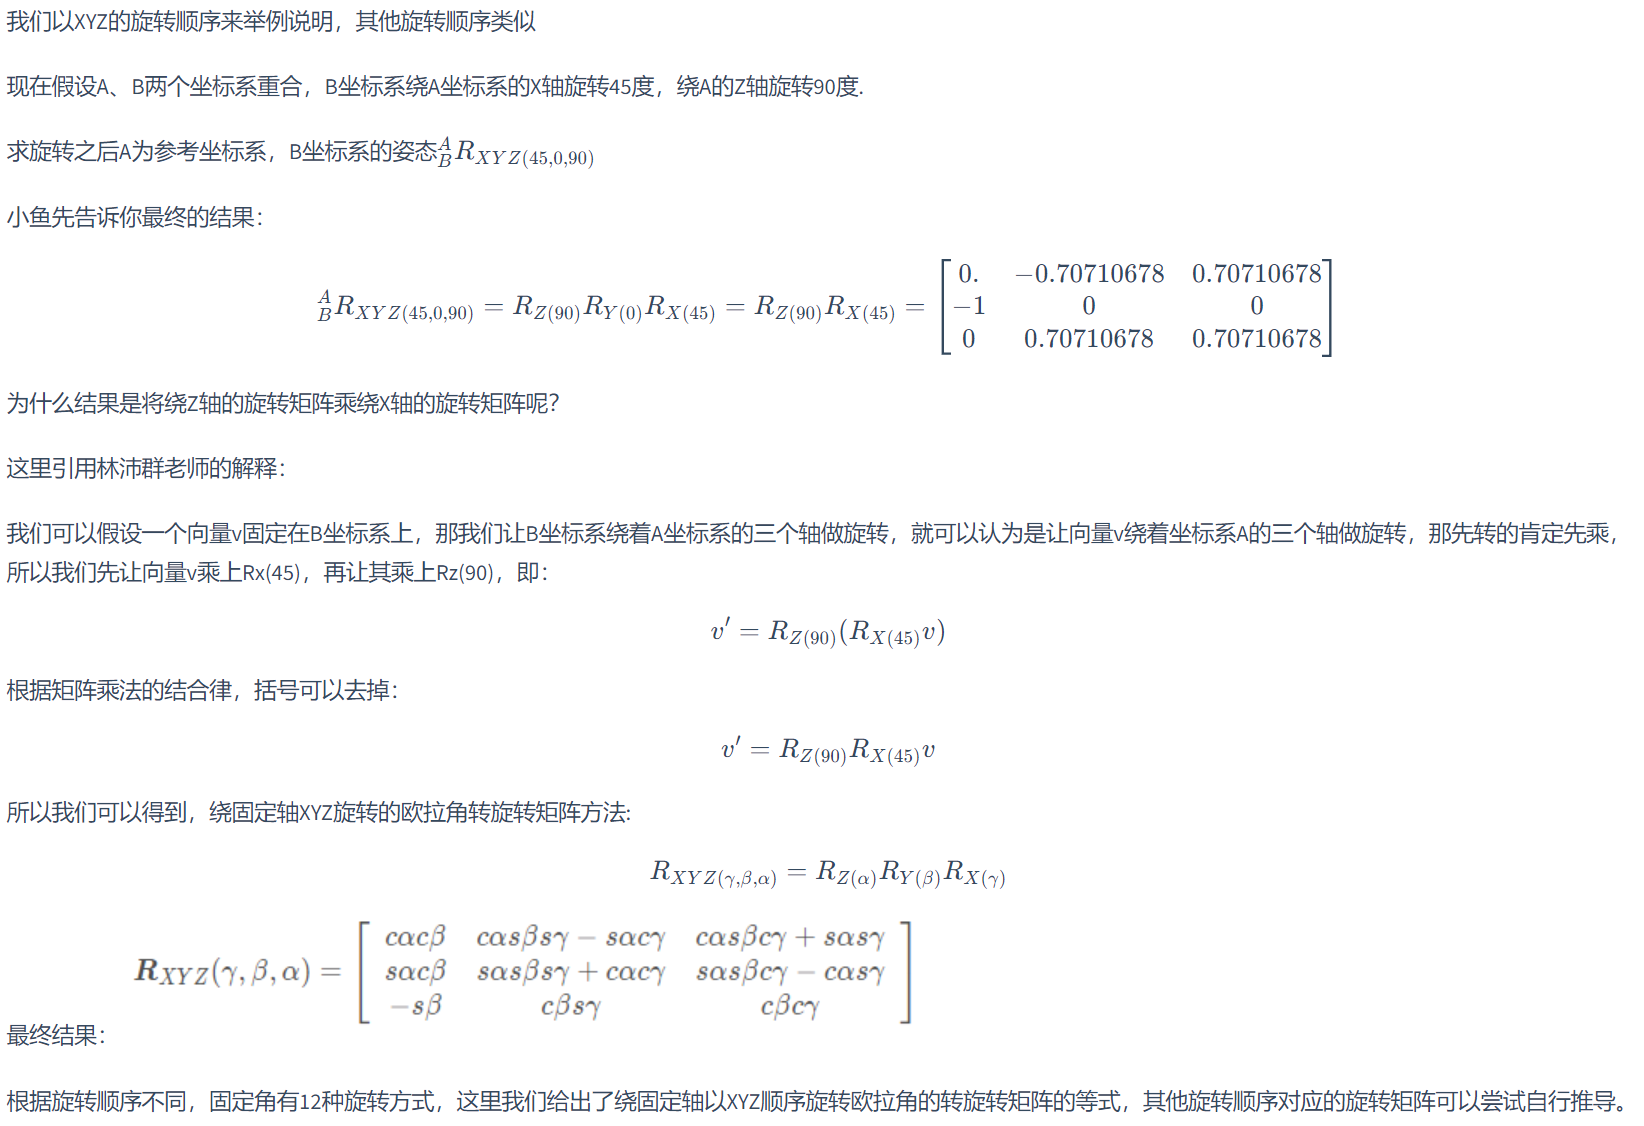

### **非固定旋转轴的欧拉角**
我们以旋转顺序ZYX为例  
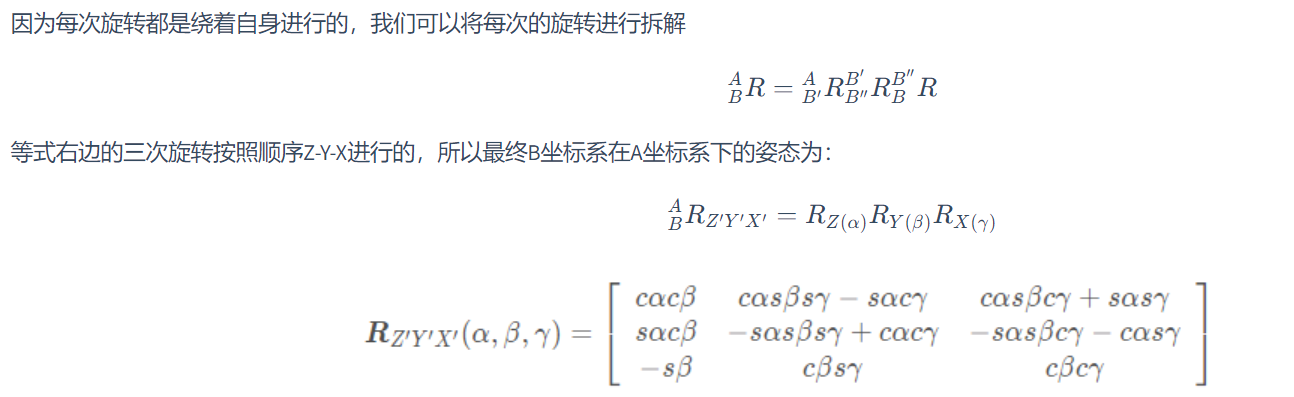
>旋转矩阵转欧拉角的方法需要使用双参变量的反正切函数，我们后面在程序当中直接调用对应函数即可实现，这里对原理就不再进行推导了

## 轴角
等效角度轴线：  

上一节欧拉角中无论是绕着自身的某个轴旋转，还是绕着固定的坐标系的某个轴进行旋转，旋转时参考的轴都是坐标系的主轴

假如我们参考的轴不是主轴，那么任何姿态都可以通过选择适当的轴和角度得到，换句话说，两个坐标系之间的任何姿态都可以通过绕某一个特定的轴(矢量)旋转特定的角度得到。

### 轴角转旋转矩阵
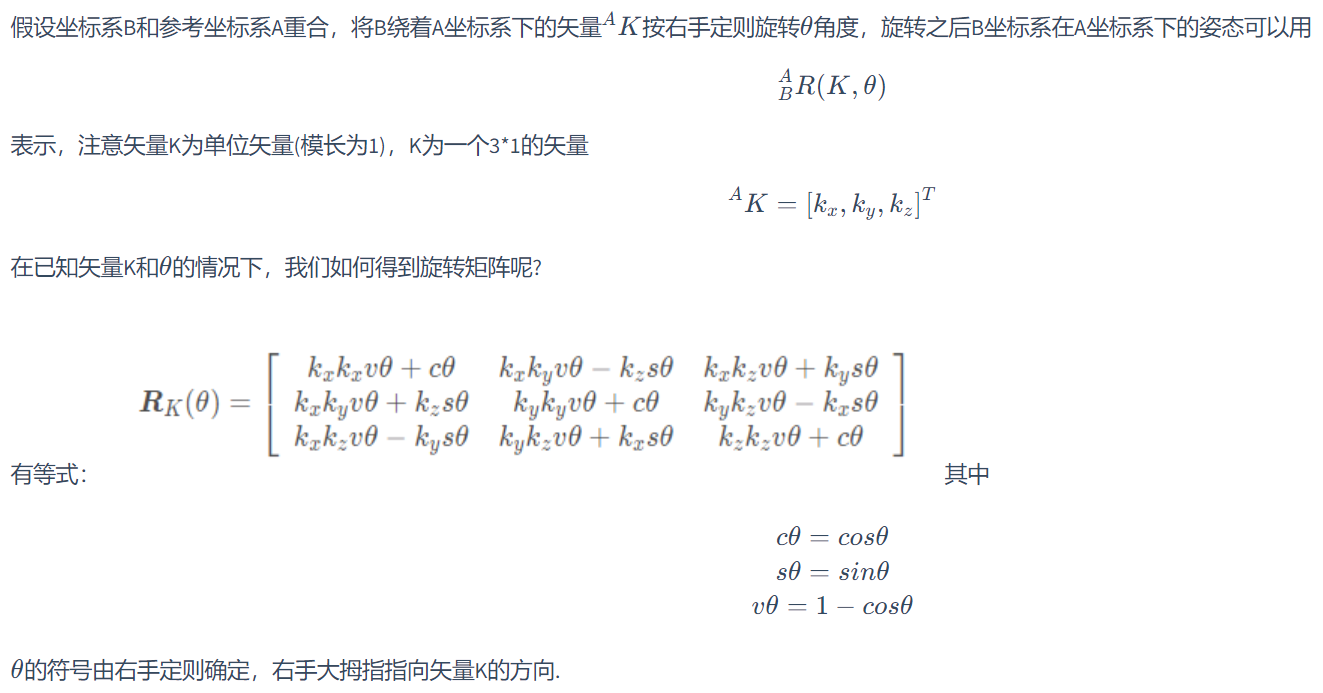

旋转矩阵转轴角需要根据情况讨论，该部分转换我们直接调用相应函数实现，这里对其原理不再叙述  
参考：https://en.wikipedia.org/wiki/Rotation_matrix#Axis_of_a_rotation

## 四元数
四元数的四个数字由一个实部和三个虚部组成，是一个超复数形式``q=w+x∗i+y∗j+z∗k``

>在机器人学当中用到的四元数都是单位四元数（四维单位超球体在三维空间的投影）,下文中提到的四元数默认指单位四元数

参考：https://www.bilibili.com/video/BV1SW411y7W1/?spm_id_from=888.80997.embed_other.whitelist&t=607.674594&bvid=BV1SW411y7W1

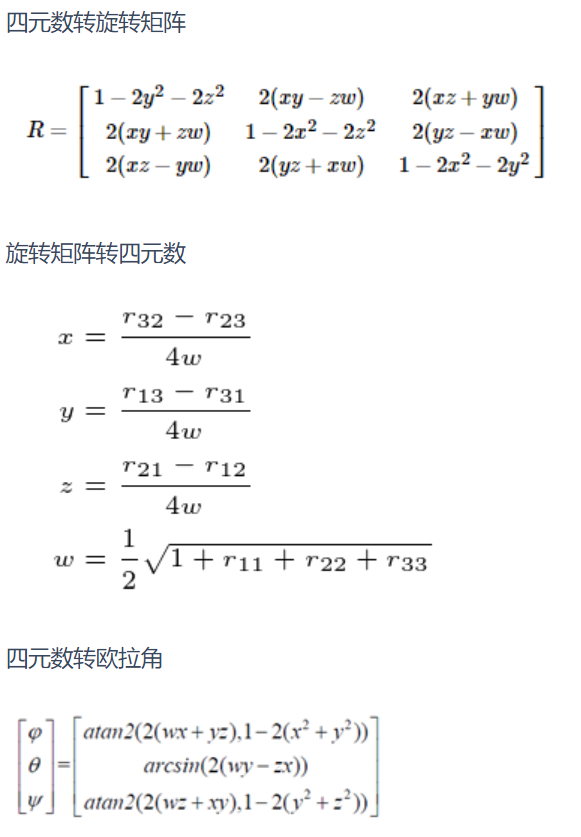
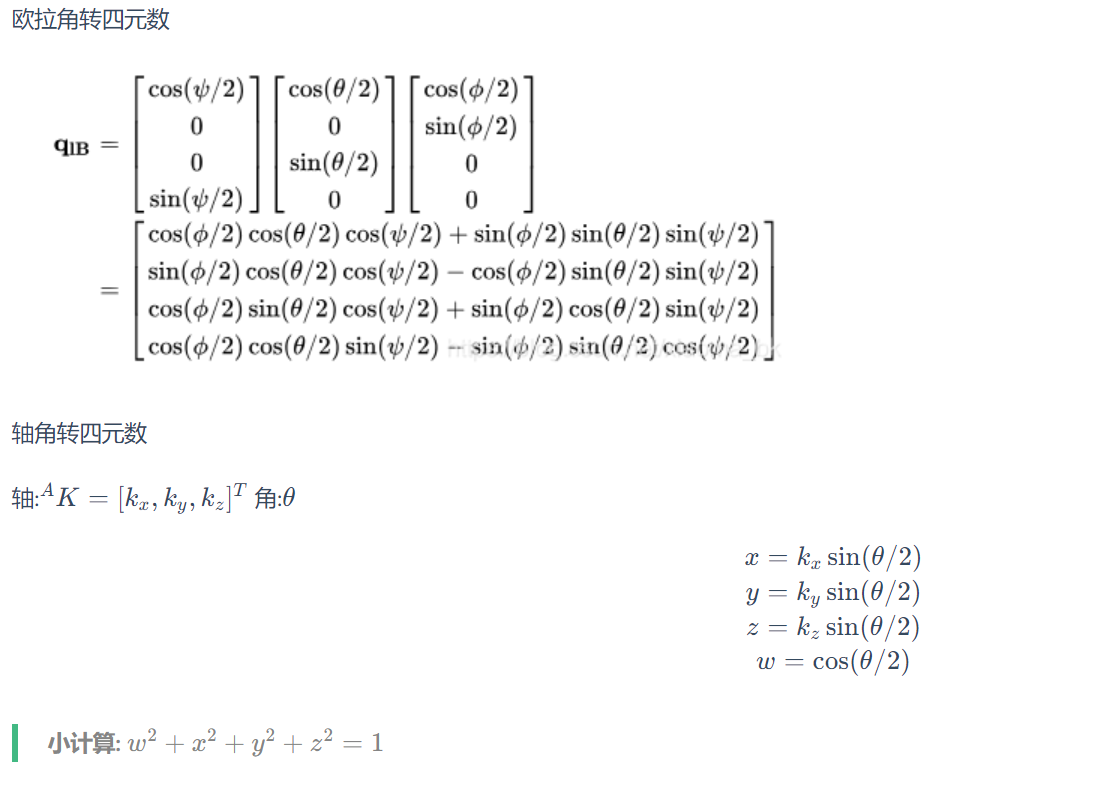

# 姿态转换实战

# 齐次坐标变换

# 齐次坐标变换实战

# TF2介绍
使用tf的坐标广播工具进行广播坐标关系，广播时需要三个数据：
- 父坐标系名称（字符串）
- 子坐标系名称（字符串）
- 父子之间的变换关系（平移关系和旋转关系）

```
ros2 run tf2_ros static_transform_publisher 
```
可以看到
```
A command line utility for manually sending a transform.
Usage: static_transform_publisher x y z qx qy qz qw frame_id child_frame_id 
OR 
Usage: static_transform_publisher x y z yaw pitch roll frame_id child_frame_id
```
这是该CLI所提供的使用提示，可以看出

使用TF发布位置和姿态时，位置的描述使用的是xyz三个参数，而姿态的描述则分两种

第一种是四元数形式（qx qy qz qw）  
第二种是欧拉角形式（yaw偏航角-rz pitch俯仰角-ry roll滚转角-rx），我们这里采用的是欧拉形式，绕x轴旋转采用欧拉角中的滚转角roll来描述，注意角度单位采用弧度制。

**发布B到C的位姿**  
父坐标系的名字就是B，子坐标系的名字是C，父子之间的平移关系是0 0 3,旋转关系是绕x轴旋转180度。  
```
ros2 run tf2_ros static_transform_publisher 0 0 3 0 0 3.14 B C
```
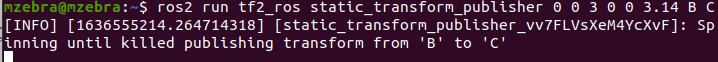

**发布C到P的位姿**  
```
ros2 run tf2_ros static_transform_publisher 2 1 2 0 0 0 C P
```


**监听/获取TF关系**  
```
ros2 run tf2_ros tf2_echo B P
```
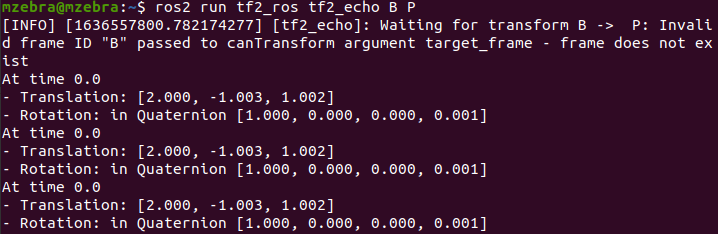   

可以看到终端中不断输出B和C之间的平移和旋转，平移采用的是xyz，基本正确，y和z的微小差异是因为我们发布变换时旋转输入的是3.14并不精确。至于旋转部分采用的是四元数表示

## TF2常用工具
**rqt_tf_tree**  

打开rqt工具，Plugins->Visualization->TF Tree

接着你就可以看到这个强大的，几乎可以实时看到系统tf更新信息的工具，这个工具对于后面我们进行导航和机械臂的调试非常有帮助。

**tf2_monitor**  
```
ros2 run tf2_ros tf2_monitor 
```

**view_frames.py**

可以生成TF的pdf，目前也有在线的实时查看工具。
```
ros2 run tf2_tools view_frames.py 
```

# RVIZ2-TF组件
运行上节的示例，打开终端输入rviz2，打开rviz2，我们尝试在rviz2中直观的看到坐标之间的关系

**1.设置默认坐标系**  

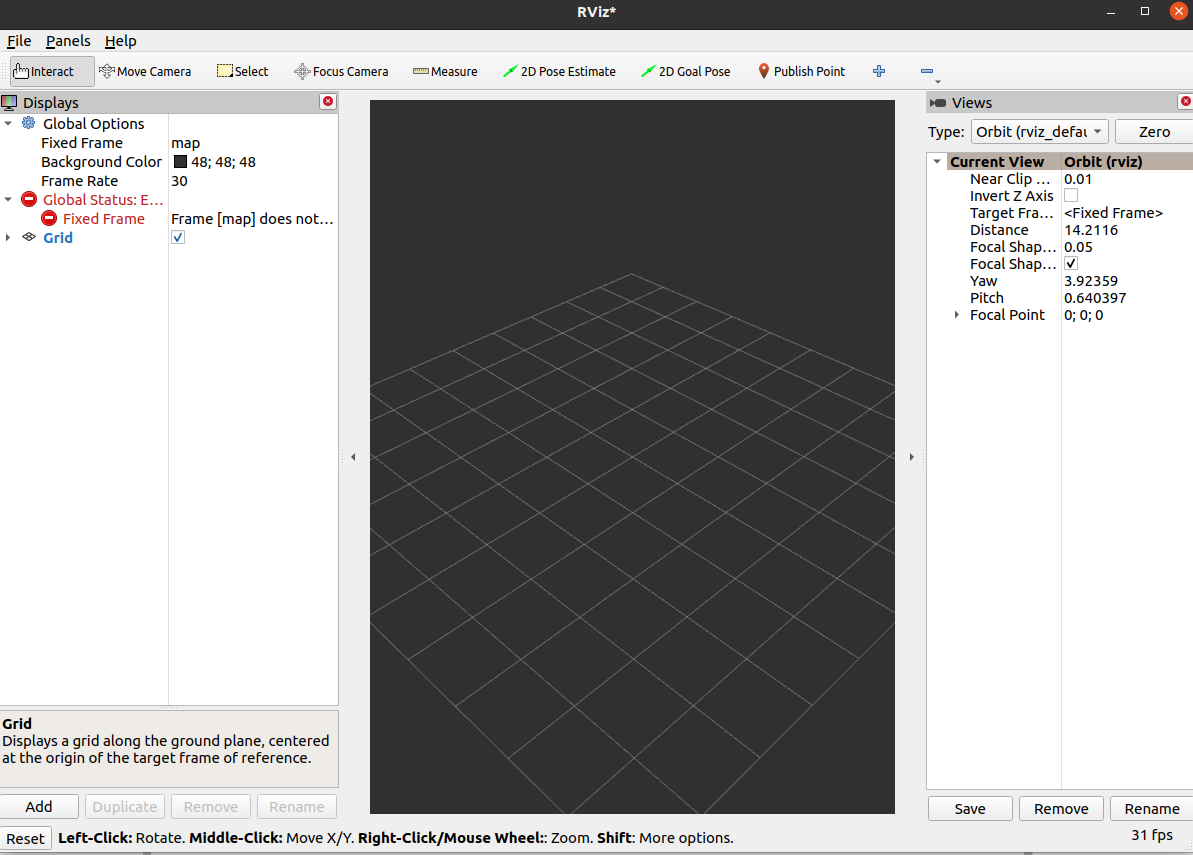

我们可以看到窗口左边的配置选项，全局选项默认选择的FixedFrame为map，这个map就是rviz2默认的坐标系的名字，动动脚趾头想一下我们并没有发布map这个坐标系，所以下面Global Status也是红色的错误。

此时我们可以手动的修改以下固定的Frame为B，让默认的坐标系设置成机械臂的基坐标系{B}。

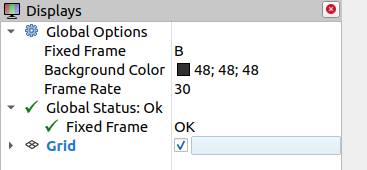

设置完成后，错误也没有了，因为此时的ROS2的TF中确确实实找到了一个叫做B的坐标系。

**2.添加TF插件**

即使没有错误，现在我们还是看不到坐标系，这是为什么呢？在小鱼的动手学ROS2课程当中，小鱼讲过，RVIZ2是一个插件化的软件，所以我们要添加TF相关的插件才能看到TF数据。

点击左下角的Add，在弹出的窗口中选择TF点击OK

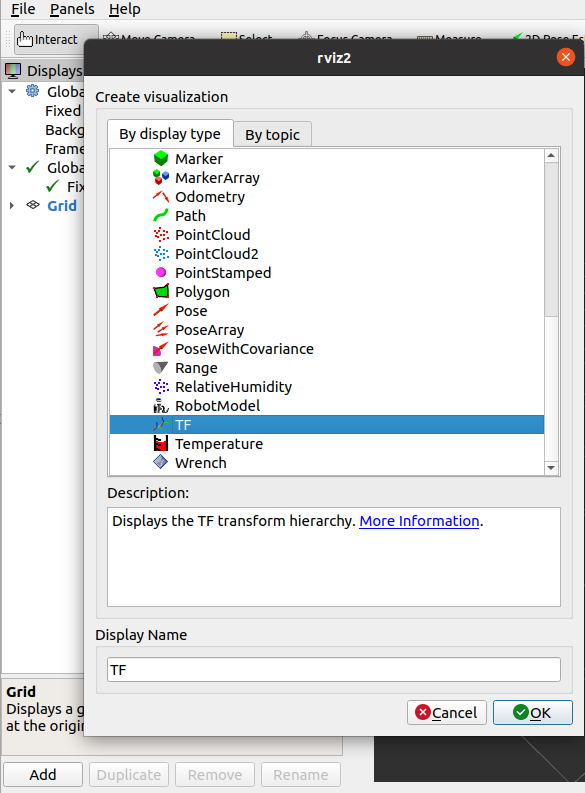

之后你在RVIZ2中就可以看到下图的坐标关系

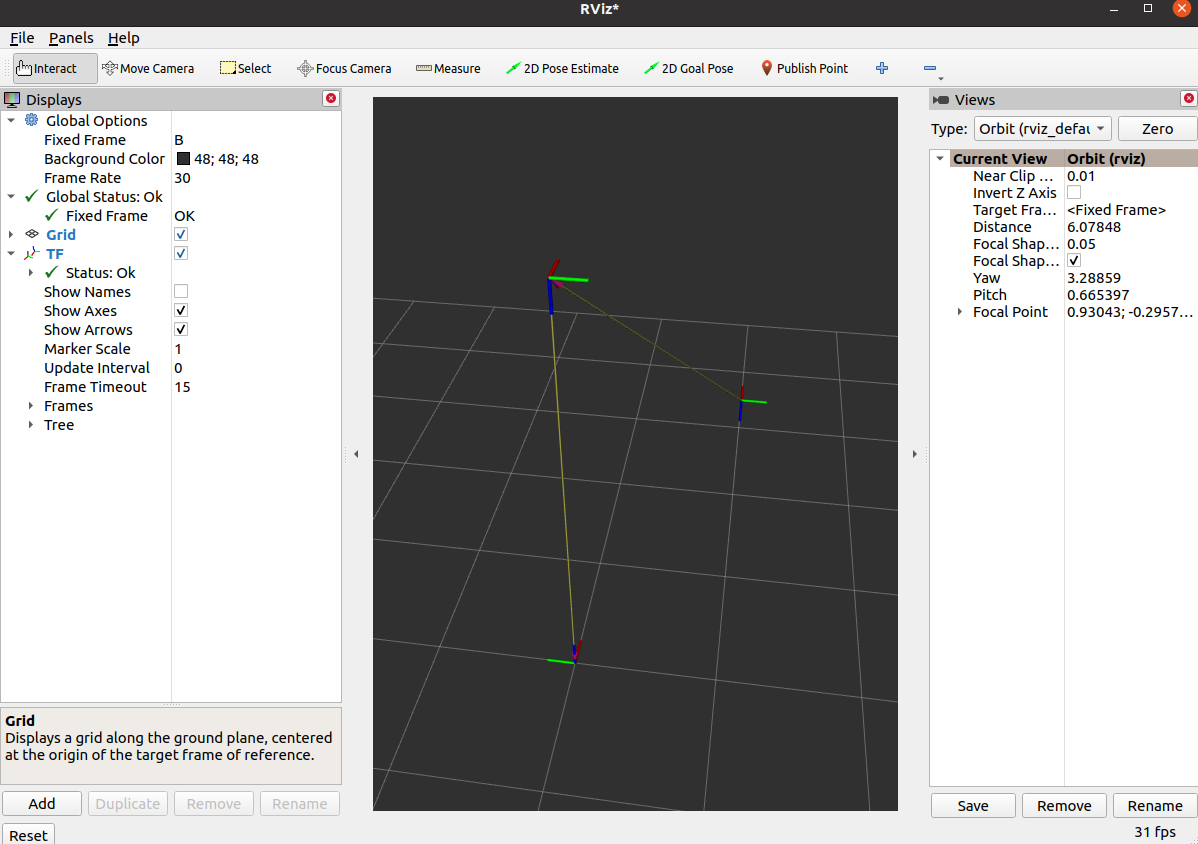

终于显示出来了，但是没有名字又太小了，修改下左边的选项，勾选Show Names，修改Marker Scale 为5

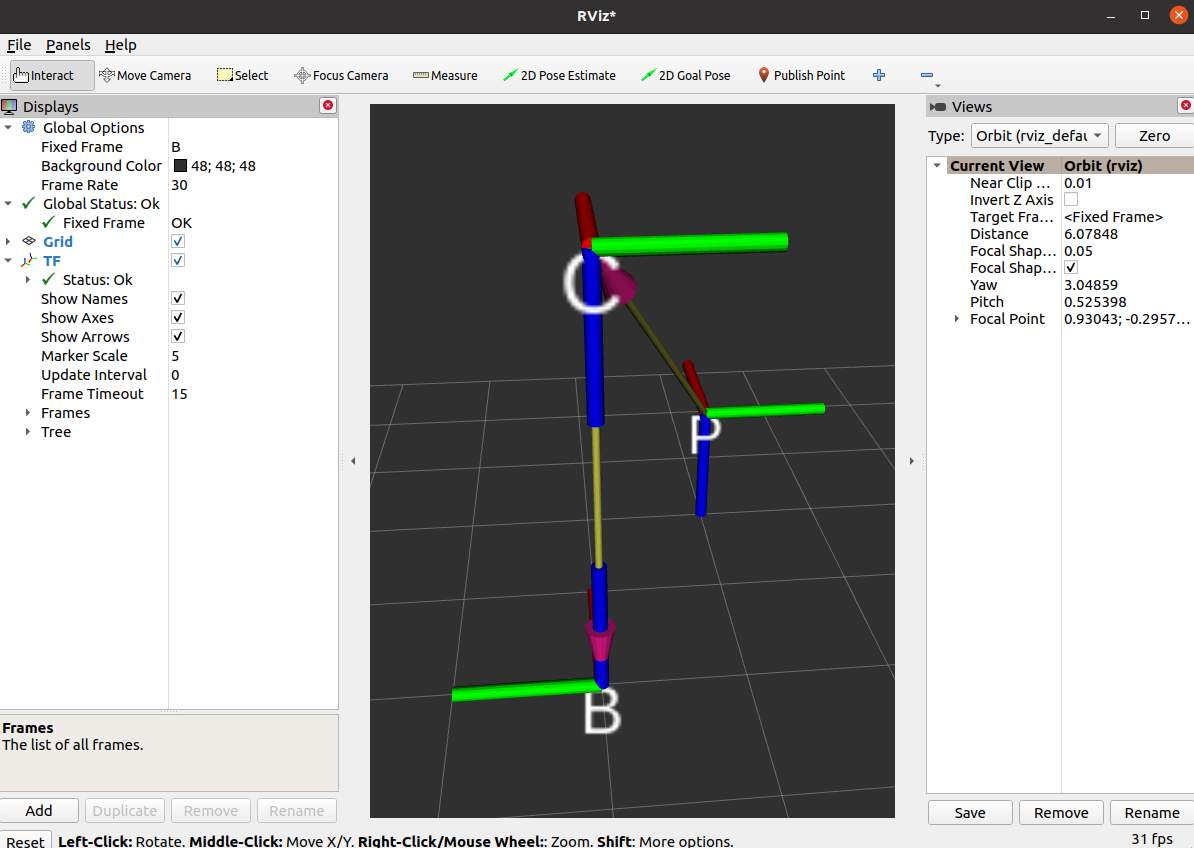

如果觉得视角不好，可以使用鼠标左键右键以及按下滚轮拖动修改。

# python实现坐标变换发布监听

# TF时间机制